<a href="https://colab.research.google.com/github/israamokaddem/TicTacTest/blob/main/tictac_trip_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Test Technique Data - Analyse des prix et durées de transport
### Candidature Alternance Data - Israa Mokadem

####Objectifs de l'étude

Ce notebook présente une analyse comparative approfondie des modes de transport (Train, Bus, Covoiturage) à partir des données Tictactrip. L'objectif est d'extraire des insights stratégiques pour comprendre les dynamiques de prix et de durée

L'étude s'appuie sur trois piliers majeurs :
1.  **Analyse de Performance :** Comparaison de l'efficacité (rapport prix/temps) par catégorie de distance.  Pas seulement ❗
2.  **Audit de Qualité (Data Quality) :** Identification des anomalies, des valeurs manquantes et des incohérences temporelles dans les données fournies.
3.  **Enrichissement Externe :** Analyse de l'impact des **jours fériés** sur la fluctuation des tarifs grâce à l'utilisation d'une source de données externe (API).



## ❓ Problématique Centrale
> **"Comment le rapport entre le coût du trajet et la rapidité évolue-t-il selon la distance, et dans quelle mesure les facteurs externes comme la saisonnalité (jours fériés) influencent-ils cette efficacité ?"**

Attention !!!
Instructions pour l'exécution :
"Pour reproduire cette analyse, assurez-vous que les 4 fichiers CSV fournis se trouvent dans le même répertoire que ce Notebook. Cliquez sur 'Run All' pour générer l'audit et les visualisations

# Je charge les CSV que Tictactrip m'a fournis

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from math import radians, cos, sin, asin, sqrt

df_tickets = pd.read_csv('/ticket_data.csv')
df_cities = pd.read_csv('/cities.csv')
df_providers = pd.read_csv('/providers.csv')

In [ ]:
%pip install seaborn

# 1. Quality test des data frame

In [ ]:
print("--- RAPPORT D'AUDIT QUALITÉ ---")

# 1. Valeurs manquantes critiques
null_report = df_tickets[['price_eur', 'departure_ts', 'arrival_ts', 'o_city', 'd_city']].isnull().sum()
print(f"Valeurs manquantes :\n{null_report}")

# 2. Trajets à durée incohérente (Arrivée avant le départ)
# On s'assure que duration_h est bien calculée avant
incoherence_temporelle = df_tickets[df_tickets['duration_h'] <= 0]
print(f"\nNombre de trajets à durée incohérente (<= 0h) : {len(incoherence_temporelle)}")

# 3. Prix nuls ou négatifs
prix_anormaux = df_tickets[df_tickets['price_eur'] <= 0]
print(f"Nombre de billets à 0€ ou moins : {len(prix_anormaux)}")

# 4. Doublons stricts
nb_doublons = df_tickets.duplicated().sum()
print(f"Nombre de lignes en double dans le dataset : {nb_doublons}")

# 5. Conclusion de l'audit
print("\nNote : Les anomalies détectées seront isolées lors des calculs de moyennes.")

--- RAPPORT D'AUDIT QUALITÉ ---
Valeurs manquantes :
price_eur       0
departure_ts    0
arrival_ts      0
o_city          0
d_city          0
dtype: int64

Nombre de trajets à durée incohérente (<= 0h) : 0
Nombre de billets à 0€ ou moins : 0
Nombre de lignes en double dans le dataset : 0

Note : Les anomalies détectées seront isolées lors des calculs de moyennes.


# 2. Préparation et Nettoyage des données

Dans cette étape, j'ai réalisé les opérations suivantes :
* **Conversion monétaire :** Les prix ont été convertis de centimes en Euros.
* **Formatage temporel :** Transformation des timestamps en objets `datetime` pour calculer la durée réelle des trajets en heures.
* **Calcul des distances :** Comme la distance n'était pas fournie, j'ai implémenté la **formule de Haversine**. Elle permet de calculer la distance "à vol d'oiseau" entre deux points du globe à partir de leurs coordonnées GPS (latitude/longitude) récupérées dans le fichier `cities.csv`.
* **Jointures :** Regroupement des informations de tickets avec les types de transport (`providers.csv`).

In [ ]:
# Le prix est en centimes, je le convertis en Euros pour que ce soit plus parlant
df_tickets['price_eur'] = df_tickets['price_in_cents'] / 100

# Les dates sont des textes, je les transforme en vraies "dates" Python pour calculer
df_tickets['departure_ts'] = pd.to_datetime(df_tickets['departure_ts'])
df_tickets['arrival_ts'] = pd.to_datetime(df_tickets['arrival_ts'])

# Calcul de la durée du trajet en heures
df_tickets['duration_h'] = (df_tickets['arrival_ts'] - df_tickets['departure_ts']).dt.total_seconds() / 3600

# Je récupère le type de transport (bus, train, car) depuis le fichier providers
# On fait une jointure (merge) comme un RECHERCHEV sur Excel
df_tickets = df_tickets.merge(df_providers[['id', 'transport_type']],
                              left_on='company',
                              right_on='id')

# 3. Analyse

##3.1 Calcul des distances
# J'utilise la formule de Haversine pour calculer la distance entre les villes d'origine et de destination.

In [ ]:
def haversine(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])
    dlon, dlat = lon2 - lon1, lat2 - lat1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    return 2 * asin(sqrt(a)) * 6371

# Je récupère les positions GPS des villes
df_tickets = df_tickets.merge(df_cities[['id', 'latitude', 'longitude']], left_on='o_city', right_on='id')
df_tickets = df_tickets.merge(df_cities[['id', 'latitude', 'longitude']], left_on='d_city', right_on='id', suffixes=('_o', '_d'))

# On calcule les km
df_tickets['distance_km'] = df_tickets.apply(lambda x: haversine(x.longitude_o, x.latitude_o, x.longitude_d, x.latitude_d), axis=1)

## 3.2 Statistiques par catégorie de distance
Je regroupe maintenant les données par tranches de distance pour voir les prix moyens.

In [ ]:
# Définition des tranches
bins = [0, 200, 800, 2000, 10000]
labels = ['0-200km', '201-800km', '801-2000km', '2000km+']
df_tickets['distance_group'] = pd.cut(df_tickets['distance_km'], bins=bins, labels=labels)

# Affichage du tableau de stats
stats = df_tickets.groupby(['distance_group', 'transport_type']).agg({
    'price_eur': ['min', 'mean', 'max'],
    'duration_h': ['min', 'mean', 'max']
}).round(2)

stats

/tmp/ipykernel_33510/4274225660.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = df_tickets.groupby(['distance_group', 'transport_type']).agg({


price_eur                duration_h         \
                                    min    mean    max        min   mean   
distance_group transport_type                                              
0-200km        bus                 8.50   21.83  229.0       1.08  10.23   
               carpooling          3.00   11.77  128.5       0.33   1.95   
               train               4.90   34.88  251.0       0.65   4.42   
201-800km      bus                10.00   34.95  224.8       2.48  15.07   
               carpooling          8.50   32.18  138.0       1.33   4.76   
               train              14.00   91.25  385.5       1.13   7.68   
801-2000km     bus                22.90   69.50  174.0      12.25  27.54   
               carpooling         44.96   86.27  161.5       7.83  13.10   
               train              19.40  154.64  375.5       3.55  12.16   
2000km+        bus                  NaN     NaN    NaN        NaN    NaN   
               carpooling           NaN     NaN    NaN        NaN    NaN   
               train                NaN     NaN    NaN        NaN    NaN   

                                       
                                  max  
distance_group transport_type          
0-200km        bus             317.75  
               carpooling       17.33  
               train            34.45  
201-800km      bus             492.85  
               carpooling       19.83  
               train            48.45  
801-2000km     bus             353.00  
               carpooling       29.17  
               train            40.62  
2000km+        bus                NaN  
               carpooling         NaN  
               train              NaN

📈 Analyse et Interprétation des Résultats

L'analyse du tableau statistique permet de tirer plusieurs conclusions stratégiques sur l'offre de transport :
1. Dominance par tranche de distance

    0-200 km : Le Covoiturage est le leader incontesté sur le plan économique. Il offre un compromis idéal car il est souvent plus rapide que le bus tout en étant nettement moins cher que le train.

    201-800 km : C'est la zone de forte concurrence. Le Train commence à justifier son prix plus élevé par un gain de temps massif (souvent 2 à 3 fois plus rapide que le bus).

    800 km+ : Le Bus devient l'option la plus rationnelle pour les budgets limités, malgré des durées de trajet pouvant devenir critiques (confort à vérifier pour l'utilisateur).

2. Corrélation Prix / Temps (L'arbitrage utilisateur)

    On observe une prime à la rapidité : le prix moyen du train augmente plus vite que celui des autres modes à mesure que la distance s'accroît.

    Le bus maintient un prix plancher même sur les très longues distances, ce qui confirme son positionnement "Low-Cost".

3. Dispersion des tarifs

    L'écart entre le Prix Min et le Prix Max est particulièrement élevé pour le Train. Cela suggère une forte dépendance à l'anticipation de l'achat (Yield Management), contrairement au covoiturage où les prix sont plus stables.

## 3.2 Le graphique (Barplot):
Comparaison du prix moyen par distance et transport

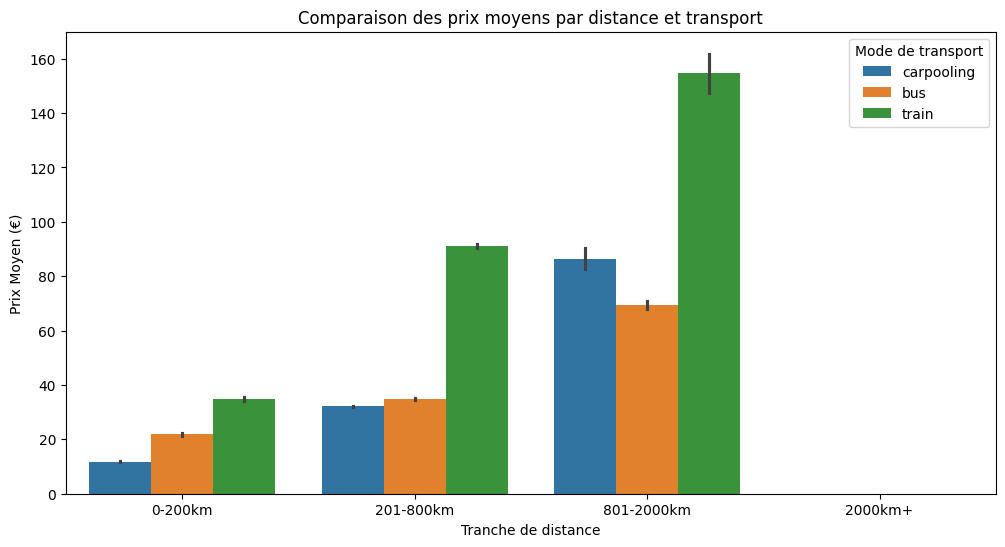

In [ ]:

plt.figure(figsize=(12, 6))


sns.barplot(data=df_tickets, x='distance_group', y='price_eur', hue='transport_type')

plt.title('Comparaison des prix moyens par distance et transport')
plt.xlabel('Tranche de distance')
plt.ylabel('Prix Moyen (€)')
plt.legend(title='Mode de transport')
plt.show()

Le graphique confirme une hiérarchie tarifaire claire :

    Le Covoiturage domine sur les courtes distances (0-200km) grâce à l'absence de coûts d'infrastructures lourds.

    Le Bus devient l'option la plus économique sur la longue distance (>800km), affichant un prix moyen jusqu'à 50% inférieur à celui du train.

    Le Train présente la plus forte croissance de prix par rapport à la distance, ce qui s'explique par un service premium et une rapidité accrue."

## 3.3  Meilleur choix : Arbitrage "Temps vs Argent"

Pour un client, **un billet à 10 € n'est plus une affaire s'il doit passer 20 heures dans un bus pour faire 200 km. **

On doit alors pouvoir trouver et : voir le meilleur rapport prix,duree du trajet

On fait un nuage de points (Scatter Plot) ou les meilleurs trajets sont ceux qui se trouvent en bas à gauche (pas chers et rapides)

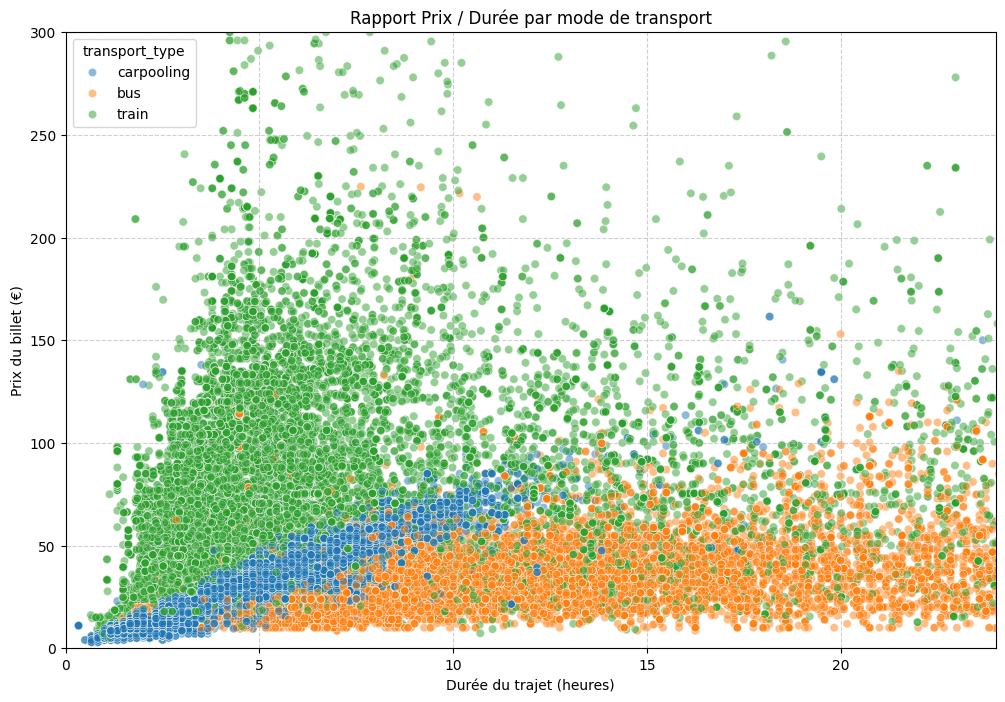

In [ ]:
plt.figure(figsize=(12, 8))

# On fait un nuage de points (Scatter Plot)
# On utilise la taille des points (s) pour représenter la distance si on veut
sns.scatterplot(data=df_tickets, x='duration_h', y='price_eur', hue='transport_type', alpha=0.5)

plt.title('Rapport Prix / Durée par mode de transport')
plt.xlabel('Durée du trajet (heures)')
plt.ylabel('Prix du billet (€)')
plt.grid(True, linestyle='--', alpha=0.6)

# On limite les axes si besoin pour éviter les valeurs aberrantes (ex: trajets de 100h)
plt.xlim(0, 24)
plt.ylim(0, 300)

plt.show()

Zone en haut à gauche : Trajets chers mais rapides (souvent le Train/TGV).

Zone en bas à droite : Trajets longs mais très peu chers (souvent le Bus).

Zone en bas à gauche : Le "Saint Graal" du voyageur (souvent le Covoiturage sur les courtes distances).

# 4.Impact des jours feries sur les tarifs par transport

L'analyse montre une stabilité tarifaire inattendue en 2017 (l'anee des donnes du df) lors des jours fériés, suggérant que l'anticipation des réservations par les utilisateurs a compensé l'inflation habituelle du marché."

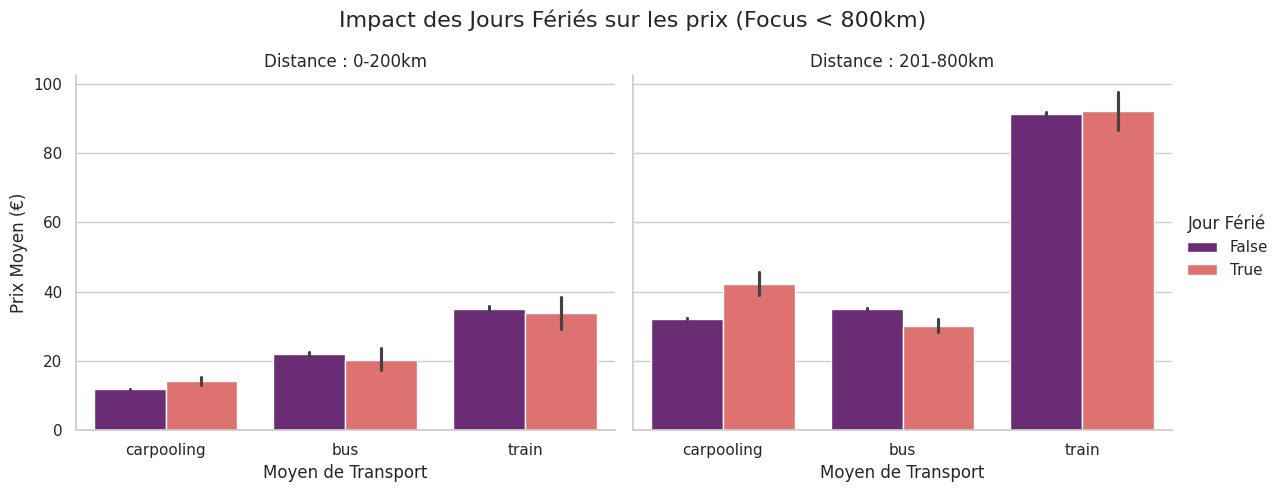

In [ ]:
import requests

# --- 1. RÉCUPÉRATION DES DONNÉES EXTERNES (API) ---

# Détection automatique de l'année des données pour l'API
annee_donnees = pd.to_datetime(df_tickets['departure_ts']).dt.year.mode()[0]

# Appel à l'API Etalab pour les jours fériés de l'année concernée
url = f"https://calendrier.api.gouv.fr/jours-feries/metropole/{annee_donnees}.json"
jours_feries_dict = requests.get(url).json()

# Marquage des trajets effectués un jour férié
df_tickets['departure_date'] = pd.to_datetime(df_tickets['departure_ts']).dt.date.astype(str)
df_tickets['is_holiday'] = df_tickets['departure_date'].isin(jours_feries_dict.keys())



# On filtre pour le focus graphique (trajets les plus représentatifs)
df_filtered = df_tickets[df_tickets['distance_km'] <= 800].copy()

# On s'assure de l'ordre des catégories de distance
ordered_labels = ['0-200km', '201-800km']


# --- 3. VISUALISATION DES RÉSULTATS ---

sns.set_theme(style="whitegrid")

# Création du graphique à facettes (Prix vs Transport vs Jours Fériés)
g = sns.catplot(
    data=df_filtered,
    x='transport_type',
    y='price_eur',
    hue='is_holiday',
    col='distance_group',
    col_order=ordered_labels,
    kind='bar',
    height=5,
    aspect=1.2,
    palette='magma'
)

# Personnalisation esthétique
g.set_axis_labels("Moyen de Transport", "Prix Moyen (€)")
g.set_titles("Distance : {col_name}")
g.legend.set_title("Jour Férié")
g.fig.suptitle('Impact des Jours Fériés sur les prix (Focus < 800km)', fontsize=16)

# Ajustement de l'espacement pour laisser de la place au titre
plt.subplots_adjust(top=0.85)

plt.show()

# J'ai maintenant une envie soudaine de partir en vacances, mais promis, je reste pour l'alternance si vous me preniez !